# Interpretabilidad de centroides y arquetipos

Este notebook analiza qué aprendieron las familias seleccionadas de K-Means y Archetypal Analysis.

El objetivo no es volver a seleccionar configuraciones ni comparar únicamente métricas globales, sino estudiar:

- las formas representadas por centroides y arquetipos;
- la composición de subtipos RRab, RRc y RRd;
- las pertenencias continuas entregadas por AA;
- la existencia de estrellas intermedias, extremas o atípicas;
- el posible valor adicional de AA frente a una asignación discreta.

In [1]:
from itertools import combinations
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.stats import kruskal, mannwhitneyu


# Ruta principal del proyecto
def encontrar_raiz_proyecto():
    """Busca la raíz del proyecto desde el directorio actual."""

    ruta_actual = Path.cwd().resolve()

    for ruta_candidata in (
        ruta_actual,
        *ruta_actual.parents,
    ):
        tiene_src = (
            ruta_candidata
            / "src"
        ).is_dir()

        tiene_notebooks = (
            ruta_candidata
            / "notebooks"
        ).is_dir()

        if tiene_src and tiene_notebooks:
            return ruta_candidata

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto."
    )


RUTA_PROYECTO = encontrar_raiz_proyecto()

print(
    "Raíz del proyecto:",
    RUTA_PROYECTO,
)


# Permitir que Python encuentre los módulos de src
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(
        0,
        str(RUTA_PROYECTO),
    )


from src.loaders import cargar_dataset
from src.metricas import ari_metric
from src.normalizacion import aplicar_normalizacion

Raíz del proyecto: C:\Users\adanm\Code\tesis


In [2]:
# Rutas de los resultados corregidos
RUTA_SELECCION_TEST = (
    RUTA_PROYECTO
    / "resultados"
    / "seleccion_familias_test_corregida.csv"
)

RUTA_EVALUACION_TEST = (
    RUTA_PROYECTO
    / "resultados"
    / "evaluacion_test_corregida"
)

RUTA_ARTEFACTOS_TEST = (
    RUTA_EVALUACION_TEST
    / "artefactos"
)


# Cargar las 15 ejecuciones seleccionadas
df_seleccion = pd.read_csv(
    RUTA_SELECCION_TEST
)


# Comprobar las familias disponibles
resumen_familias = (
    df_seleccion
    .groupby("familia_test")
    .agg(
        n_ejecuciones=("experiment_id", "size"),
        n_semillas=("seed_modelo", "nunique"),
        semillas=(
            "seed_modelo",
            lambda valores: sorted(valores.tolist()),
        ),
        normalizaciones=(
            "normalizacion",
            lambda valores: sorted(valores.unique().tolist()),
        ),
        valores_k=(
            "K",
            lambda valores: sorted(valores.unique().tolist()),
        ),
    )
)


print(
    f"Dimensiones de la selección: "
    f"{df_seleccion.shape}"
)

display(resumen_familias)

Dimensiones de la selección: (15, 10)


,n_ejecuciones,n_semillas,semillas,normalizaciones,valores_k
familia_test,,,,,
aa_principal_k5,5,5,"[0, 1, 2, 3, 4]",[minmax],[5]
kmeans_comparacion_k5,5,5,"[0, 1, 2, 3, 4]",[minmax],[5]
kmeans_principal_k4,5,5,"[0, 1, 2, 3, 4]",[zscore],[4]


In [3]:
# Calcular la representatividad de cada semilla en validación
representatividad_semillas = []


for familia_test, grupo_familia in (
    df_seleccion.groupby("familia_test")
):

    asignaciones = {}
    ids_referencia = None

    for _, ejecucion in grupo_familia.iterrows():

        carpeta_experimento = (
            RUTA_PROYECTO
            / Path(ejecucion["ruta_experimento"])
        )

        grupos_val = np.load(
            carpeta_experimento / "grupos_val.npy"
        )

        ids_val = np.load(
            carpeta_experimento / "ids_val.npy",
            allow_pickle=True,
        )

        if ids_referencia is None:
            ids_referencia = ids_val

        elif not np.array_equal(
            ids_referencia,
            ids_val,
        ):
            raise ValueError(
                f"Los IDs de validación no coinciden "
                f"en la familia {familia_test}."
            )

        asignaciones[
            ejecucion["experiment_id"]
        ] = {
            "seed_modelo": ejecucion["seed_modelo"],
            "grupos_val": grupos_val,
        }

    for experiment_id, contenido in asignaciones.items():

        ari_con_otras = []

        for otro_experiment_id, otro_contenido in (
            asignaciones.items()
        ):
            if otro_experiment_id == experiment_id:
                continue

            ari_con_otras.append(
                ari_metric(
                    contenido["grupos_val"],
                    otro_contenido["grupos_val"],
                )
            )

        representatividad_semillas.append(
            {
                "familia_test": familia_test,
                "experiment_id": experiment_id,
                "seed_modelo": contenido["seed_modelo"],
                "ari_medio_con_otras": np.mean(
                    ari_con_otras
                ),
                "ari_minimo_con_otras": np.min(
                    ari_con_otras
                ),
            }
        )


df_representatividad = pd.DataFrame(
    representatividad_semillas
)


# Elegir la semilla más central de cada familia
df_ejecuciones_representativas = (
    df_representatividad
    .sort_values(
        [
            "familia_test",
            "ari_medio_con_otras",
            "ari_minimo_con_otras",
            "seed_modelo",
        ],
        ascending=[
            True,
            False,
            False,
            True,
        ],
    )
    .groupby(
        "familia_test",
        as_index=False,
    )
    .head(1)
    .reset_index(drop=True)
)


display(
    df_representatividad.sort_values(
        [
            "familia_test",
            "ari_medio_con_otras",
        ],
        ascending=[True, False],
    )
)

print("\nEjecuciones representativas:")

display(df_ejecuciones_representativas)

,familia_test,experiment_id,seed_modelo,ari_medio_con_otras,ari_minimo_con_otras
4,aa_principal_k5,976409505a67e4f6,4,0.999829,0.999658
0,aa_principal_k5,130b477559867762,0,0.999829,0.999658
1,aa_principal_k5,4dd949ada25b888e,1,0.999829,0.999658
2,aa_principal_k5,37dedb2834a007b2,2,0.999744,0.999658
3,aa_principal_k5,349e82cdd54799e0,3,0.999744,0.999658
7,kmeans_comparacion_k5,bab52ec2e2b2b05e,2,0.863723,0.464951
9,kmeans_comparacion_k5,b35af81b5b6f2d41,4,0.863723,0.464951
8,kmeans_comparacion_k5,0e3ab51d5d164b07,3,0.863714,0.464921
5,kmeans_comparacion_k5,a50d5ee7f3724c42,0,0.859142,0.464880
6,kmeans_comparacion_k5,9ea73bea4e48a1be,1,0.464926,0.464880



Ejecuciones representativas:


,familia_test,experiment_id,seed_modelo,ari_medio_con_otras,ari_minimo_con_otras
0,aa_principal_k5,976409505a67e4f6,4,0.999829,0.999658
1,kmeans_comparacion_k5,bab52ec2e2b2b05e,2,0.863723,0.464951
2,kmeans_principal_k4,a1a7966d1e8b0140,3,0.998606,0.995440


In [4]:
# Incorporar la configuración y ruta de cada ejecución representativa
df_representativas = (
    df_ejecuciones_representativas
    .merge(
        df_seleccion,
        on=[
            "familia_test",
            "experiment_id",
            "seed_modelo",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values("familia_test")
    .reset_index(drop=True)
)


display(
    df_representativas[
        [
            "familia_test",
            "experiment_id",
            "modelo",
            "K",
            "seed_modelo",
            "ari_medio_con_otras",
            "ari_minimo_con_otras",
            "ruta_experimento",
        ]
    ]
)

,familia_test,experiment_id,modelo,K,seed_modelo,ari_medio_con_otras,ari_minimo_con_otras,ruta_experimento
0,aa_principal_k5,976409505a67e4f6,archetypal_analysis,5,4,0.999829,0.999658,resultados\experimentos\976409505a67e4f6
1,kmeans_comparacion_k5,bab52ec2e2b2b05e,kmeans,5,2,0.863723,0.464951,resultados\experimentos\bab52ec2e2b2b05e
2,kmeans_principal_k4,a1a7966d1e8b0140,kmeans,4,3,0.998606,0.995440,resultados\experimentos\a1a7966d1e8b0140


In [5]:
# Diccionario para almacenar los artefactos representativos
artefactos_representativos = {}


for _, ejecucion in df_representativas.iterrows():

    familia = ejecucion["familia_test"]
    experiment_id = ejecucion["experiment_id"]

    # Carpeta del experimento entrenado
    ruta_experimento = (
        RUTA_PROYECTO
        / Path(ejecucion["ruta_experimento"])
    )

    # Carpeta con los resultados corregidos en test
    ruta_test = (
        RUTA_ARTEFACTOS_TEST
        / experiment_id
    )

    # Patrones aprendidos exclusivamente con entrenamiento
    patrones = np.load(
        ruta_experimento / "patrones.npy"
    )

    # Asignaciones obtenidas sobre el conjunto de test
    grupos_test = np.load(
        ruta_test / "grupos_test.npy"
    )

    artefactos_familia = {
        "patrones": patrones,
        "grupos_test": grupos_test,
    }

    # AA también posee coeficientes continuos
    if ejecucion["modelo"] == "archetypal_analysis":
        artefactos_familia["alphas_test"] = np.load(
            ruta_test / "alphas_test.npy"
        )

    artefactos_representativos[familia] = (
        artefactos_familia
    )


# Resumir las dimensiones de los artefactos cargados
resumen_artefactos = []

for familia, artefactos in (
    artefactos_representativos.items()
):

    resumen_artefactos.append(
        {
            "familia_test": familia,
            "forma_patrones": artefactos["patrones"].shape,
            "forma_grupos_test": (
                artefactos["grupos_test"].shape
            ),
            "forma_alphas_test": (
                artefactos["alphas_test"].shape
                if "alphas_test" in artefactos
                else None
            ),
        }
    )


df_resumen_artefactos = pd.DataFrame(
    resumen_artefactos
)

display(df_resumen_artefactos)

,familia_test,forma_patrones,forma_grupos_test,forma_alphas_test
0,aa_principal_k5,"(5, 50)","(20537,)","(20537, 5)"
1,kmeans_comparacion_k5,"(5, 50)","(20537,)",None
2,kmeans_principal_k4,"(4, 50)","(20537,)",None


In [6]:
# Cargar las particiones del dataset seleccionado
datos_mediana_50 = cargar_dataset(
    "medianas_fase_50"
)


# Extraer el conjunto de test y sus metadatos
X_test_original = datos_mediana_50["test"]["X"]

metadata_test = (
    datos_mediana_50["test"]["metadata"]
    .copy()
)


# Aplicar la normalización correspondiente a cada familia
X_test_kmeans_k4 = aplicar_normalizacion(
    X_test_original,
    "zscore",
)

X_test_kmeans_k5 = aplicar_normalizacion(
    X_test_original,
    "minmax",
)

X_test_aa = aplicar_normalizacion(
    X_test_original,
    "minmax",
)


# Resumir las dimensiones obtenidas
resumen_test = pd.Series(
    {
        "forma_test_original": X_test_original.shape,
        "forma_kmeans_k4_zscore": (
            X_test_kmeans_k4.shape
        ),
        "forma_kmeans_k5_minmax": (
            X_test_kmeans_k5.shape
        ),
        "forma_aa_k5_minmax": X_test_aa.shape,
        "filas_metadata": len(metadata_test),
        "observaciones_unicas": (
            metadata_test["observacion_id"].nunique()
        ),
    },
    name="resultado",
)

display(resumen_test)

forma_test_original       (20537, 50)
forma_kmeans_k4_zscore    (20537, 50)
forma_kmeans_k5_minmax    (20537, 50)
forma_aa_k5_minmax        (20537, 50)
filas_metadata                  20537
observaciones_unicas            20537
Name: resultado, dtype: object

In [7]:
# Cargar los identificadores usados en la evaluación corregida
ids_test_guardados = np.load(
    RUTA_EVALUACION_TEST
    / "ids_test.npy",
    allow_pickle=True,
)


# Obtener los identificadores en el orden actual
ids_test_actuales = (
    metadata_test["observacion_id"]
    .to_numpy()
)


# Comprobar la correspondencia fila a fila
mismos_ids_test = np.array_equal(
    ids_test_actuales,
    ids_test_guardados,
)


# Verificar también las cantidades de asignaciones
# y coeficientes
comprobacion_alineacion = pd.Series(
    {
        "mismos_ids_y_orden": mismos_ids_test,
        "n_ids_guardados": len(ids_test_guardados),
        "n_ids_actuales": len(ids_test_actuales),
        "n_grupos_aa": len(
            artefactos_representativos[
                "aa_principal_k5"
            ]["grupos_test"]
        ),
        "n_alphas_aa": len(
            artefactos_representativos[
                "aa_principal_k5"
            ]["alphas_test"]
        ),
        "n_grupos_kmeans_k5": len(
            artefactos_representativos[
                "kmeans_comparacion_k5"
            ]["grupos_test"]
        ),
        "n_grupos_kmeans_k4": len(
            artefactos_representativos[
                "kmeans_principal_k4"
            ]["grupos_test"]
        ),
    },
    name="resultado",
)

display(comprobacion_alineacion)


if not mismos_ids_test:
    raise ValueError(
        "El orden de metadata_test no coincide con los "
        "artefactos corregidos."
    )

mismos_ids_y_orden     True
n_ids_guardados       20537
n_ids_actuales        20537
n_grupos_aa           20537
n_alphas_aa           20537
n_grupos_kmeans_k5    20537
n_grupos_kmeans_k4    20537
Name: resultado, dtype: object

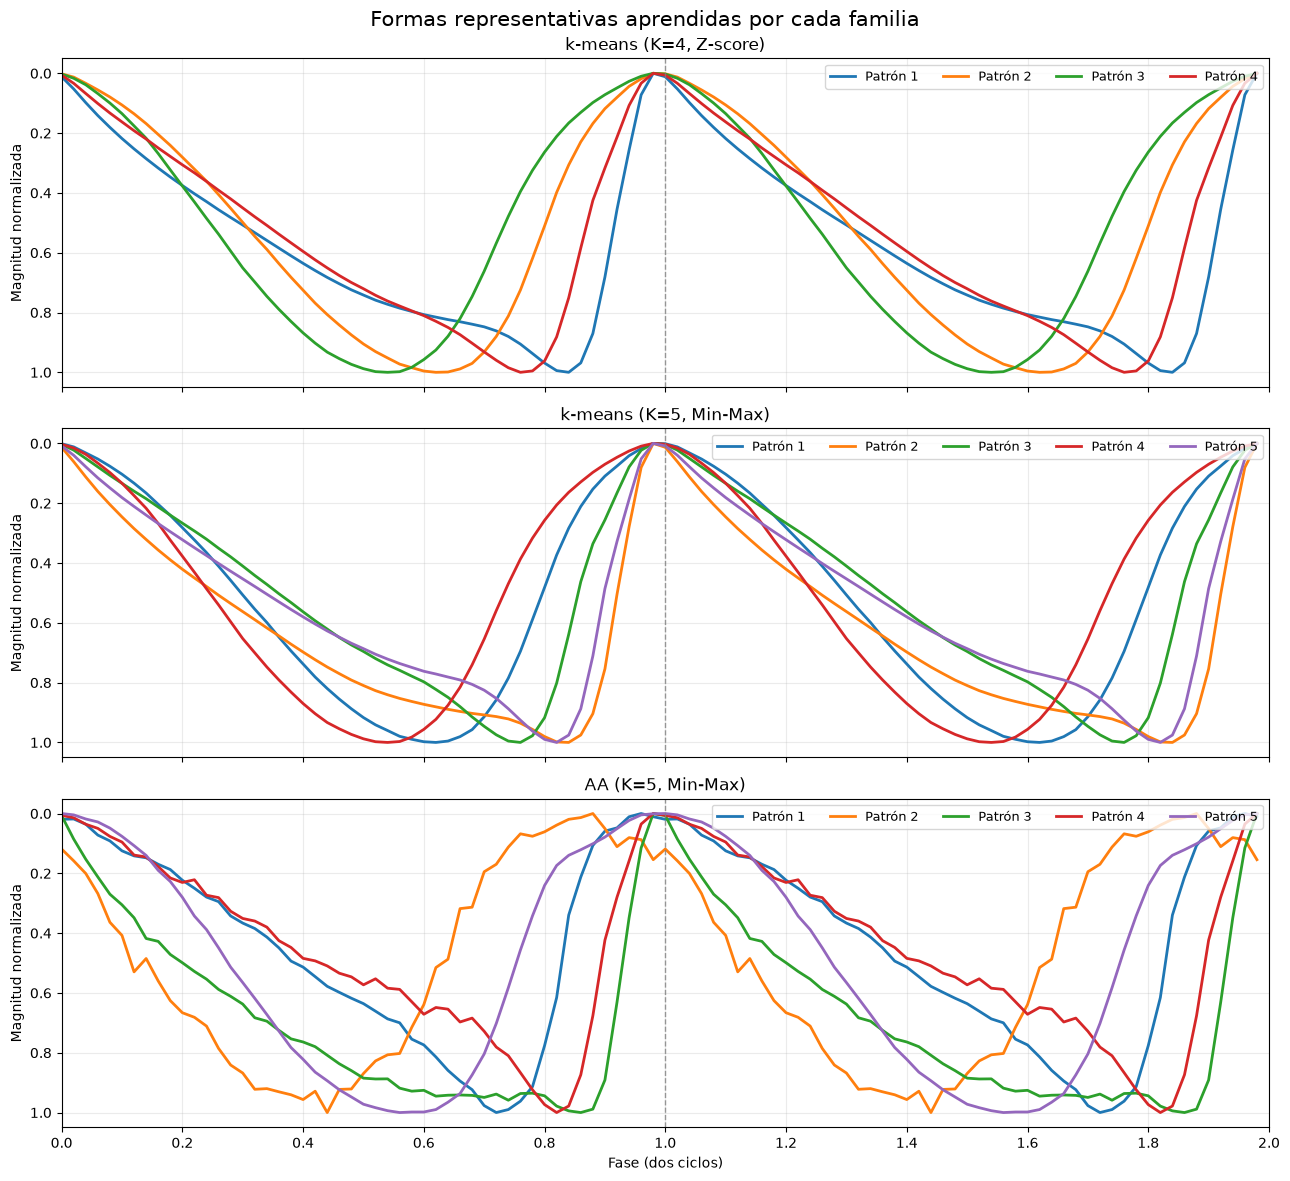

In [8]:
# Nombres más legibles para las familias
nombres_familias = {
    "kmeans_principal_k4": (
        "k-means (K=4, Z-score)"
    ),
    "kmeans_comparacion_k5": (
        "k-means (K=5, Min-Max)"
    ),
    "aa_principal_k5": (
        "AA (K=5, Min-Max)"
    ),
}


# Orden de presentación
orden_familias = [
    "kmeans_principal_k4",
    "kmeans_comparacion_k5",
    "aa_principal_k5",
]


# Crear la figura
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(13, 12),
    sharex=True,
)


for ax, familia in zip(axes, orden_familias):

    patrones = artefactos_representativos[
        familia
    ]["patrones"]

    n_puntos = patrones.shape[1]

    # Fases correspondientes a un ciclo
    fase_un_ciclo = np.arange(n_puntos) / n_puntos

    # Repetir el eje de fase para mostrar dos ciclos
    fase_doble = np.concatenate(
        [
            fase_un_ciclo,
            fase_un_ciclo + 1,
        ]
    )

    for indice, patron in enumerate(patrones):

        # Normalización individual utilizada únicamente
        # para comparar la morfología de los patrones
        minimo = patron.min()
        amplitud = patron.max() - minimo

        if amplitud > 0:
            patron_visual = (
                patron - minimo
            ) / amplitud
        else:
            patron_visual = np.zeros_like(patron)

        # Repetir el patrón durante dos ciclos
        patron_doble = np.tile(
            patron_visual,
            2,
        )

        ax.plot(
            fase_doble,
            patron_doble,
            linewidth=2,
            label=f"Patrón {indice + 1}",
        )

    ax.set_title(
        nombres_familias[familia]
    )

    ax.set_ylabel(
        "Magnitud normalizada"
    )

    # Una magnitud menor representa un mayor brillo
    ax.invert_yaxis()

    ax.set_xlim(
        0,
        2,
    )

    ax.set_xticks(
        np.arange(0, 2.01, 0.2)
    )

    # Señalar el comienzo del segundo ciclo
    ax.axvline(
        1,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.8,
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend(
        loc="upper right",
        ncol=len(patrones),
        fontsize=9,
    )


axes[-1].set_xlabel(
    "Fase (dos ciclos)"
)

fig.suptitle(
    "Formas representativas aprendidas por cada familia",
    fontsize=15,
)

plt.tight_layout()
plt.show()

In [9]:
# Construir una tabla con las asignaciones de test
# para cada una de las tres familias
tablas_asignaciones = []

for familia in orden_familias:

    grupos_test = artefactos_representativos[
        familia
    ]["grupos_test"]

    tabla_familia = pd.DataFrame(
        {
            "familia_test": familia,
            "grupo": grupos_test.astype(int) + 1,
            "subtipo_rrlyrae": (
                metadata_test["subtipo_rrlyrae"]
                .to_numpy()
            ),
        }
    )

    tablas_asignaciones.append(
        tabla_familia
    )


df_asignaciones_test = pd.concat(
    tablas_asignaciones,
    ignore_index=True,
)


# Contar los subtipos presentes en cada grupo
df_composicion_grupos = (
    df_asignaciones_test
    .groupby(
        [
            "familia_test",
            "grupo",
            "subtipo_rrlyrae",
        ]
    )
    .size()
    .rename("n_observaciones")
    .reset_index()
)


# Calcular el porcentaje que representa cada subtipo
# dentro de su grupo
df_composicion_grupos[
    "porcentaje_en_grupo"
] = (
    df_composicion_grupos["n_observaciones"]
    / df_composicion_grupos
      .groupby(
          [
              "familia_test",
              "grupo",
          ]
      )["n_observaciones"]
      .transform("sum")
    * 100
)


# Crear una tabla compacta de porcentajes
tabla_porcentajes = (
    df_composicion_grupos
    .pivot(
        index=[
            "familia_test",
            "grupo",
        ],
        columns="subtipo_rrlyrae",
        values="porcentaje_en_grupo",
    )
    .fillna(0)
    .round(2)
    .reset_index()
)


# Añadir el tamaño total de cada grupo
tamanos_grupos = (
    df_asignaciones_test
    .groupby(
        [
            "familia_test",
            "grupo",
        ]
    )
    .size()
    .rename("n_total")
    .reset_index()
)


tabla_composicion = (
    tamanos_grupos
    .merge(
        tabla_porcentajes,
        on=[
            "familia_test",
            "grupo",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "familia_test",
            "grupo",
        ]
    )
    .reset_index(drop=True)
)


display(tabla_composicion)

,familia_test,grupo,n_total,RRab,RRc,RRd
0,aa_principal_k5,1,3878,79.29,13.95,6.76
1,aa_principal_k5,2,489,9.00,87.12,3.89
2,aa_principal_k5,3,6181,98.01,0.29,1.70
3,aa_principal_k5,4,5225,99.33,0.46,0.21
4,aa_principal_k5,5,4764,5.27,89.48,5.25
5,kmeans_comparacion_k5,1,3594,22.37,63.88,13.75
6,kmeans_comparacion_k5,2,5915,99.51,0.02,0.47
7,kmeans_comparacion_k5,3,3378,94.43,3.76,1.81
8,kmeans_comparacion_k5,4,2974,2.32,95.73,1.95
9,kmeans_comparacion_k5,5,4676,99.85,0.02,0.13


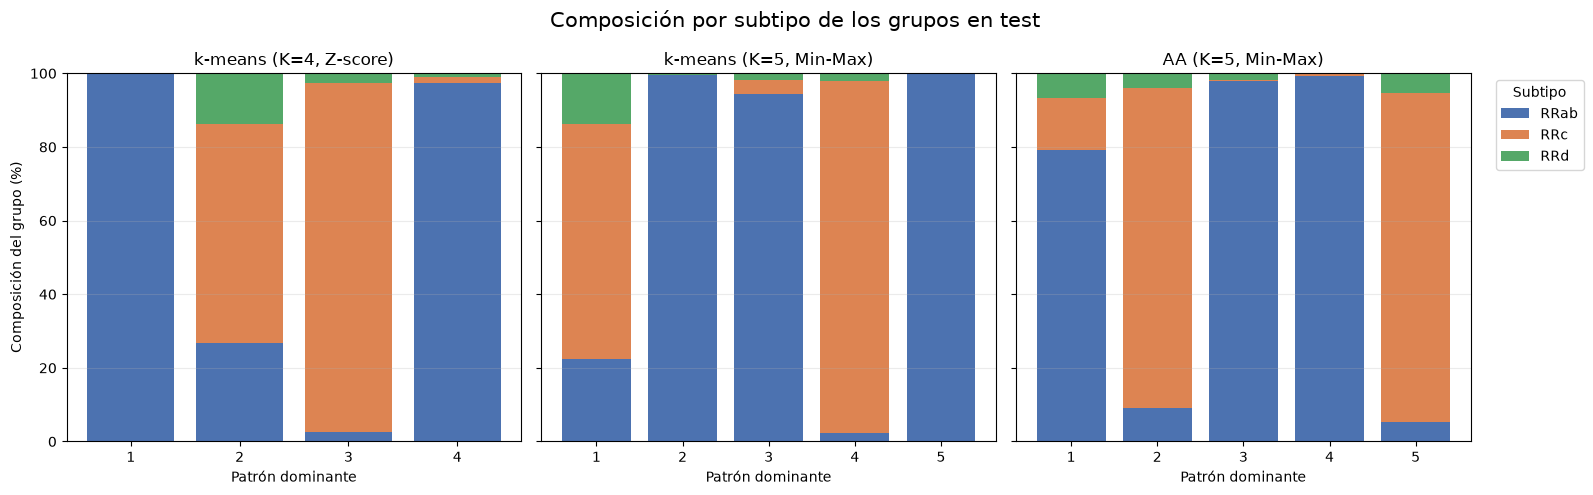

In [10]:
# Colores consistentes para los subtipos
colores_subtipos = {
    "RRab": "#4C72B0",
    "RRc": "#DD8452",
    "RRd": "#55A868",
}


# Crear un panel para cada familia
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5),
    sharey=True,
)


for ax, familia in zip(axes, orden_familias):

    tabla_familia = (
        tabla_composicion
        .loc[
            tabla_composicion["familia_test"] == familia
        ]
        .set_index("grupo")
    )

    base = np.zeros(
        len(tabla_familia)
    )

    for subtipo in ["RRab", "RRc", "RRd"]:

        valores = (
            tabla_familia[subtipo]
            .to_numpy()
        )

        ax.bar(
            tabla_familia.index.astype(str),
            valores,
            bottom=base,
            color=colores_subtipos[subtipo],
            label=subtipo,
        )

        base = base + valores

    ax.set_title(
        nombres_familias[familia]
    )

    ax.set_xlabel(
        "Patrón dominante"
    )

    ax.set_ylim(
        0,
        100,
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )


axes[0].set_ylabel(
    "Composición del grupo (%)"
)

axes[-1].legend(
    title="Subtipo",
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)

fig.suptitle(
    "Composición por subtipo de los grupos en test",
    fontsize=15,
)

plt.tight_layout()
plt.show()

In [12]:
# Recuperar los coeficientes continuos de AA
alphas_aa = artefactos_representativos[
    "aa_principal_k5"
]["alphas_test"]


# Ordenar los coeficientes de mayor a menor por estrella
alphas_ordenados = np.sort(
    alphas_aa,
    axis=1,
)[:, ::-1]


# Evitar problemas numéricos al calcular logaritmos
alphas_seguras = np.clip(
    alphas_aa,
    1e-12,
    1,
)


# Entropía normalizada:
# 0 indica dominio completo de un arquetipo
# 1 indica pesos iguales entre todos los arquetipos
entropia_normalizada = (
    -np.sum(
        alphas_seguras * np.log(alphas_seguras),
        axis=1,
    )
    / np.log(alphas_aa.shape[1])
)


# Crear una tabla por estrella
df_mezcla_aa = pd.DataFrame(
    {
        "observacion_id": (
            metadata_test["observacion_id"]
            .to_numpy()
        ),
        "subtipo_rrlyrae": (
            metadata_test["subtipo_rrlyrae"]
            .to_numpy()
        ),
        "arquetipo_dominante": (
            np.argmax(alphas_aa, axis=1) + 1
        ),
        "alpha_maximo": alphas_ordenados[:, 0],
        "alpha_segundo": alphas_ordenados[:, 1],
        "margen_dominancia": (
            alphas_ordenados[:, 0]
            - alphas_ordenados[:, 1]
        ),
        "entropia_normalizada": entropia_normalizada,
        "n_arquetipos_alpha_010": (
            alphas_aa >= 0.10
        ).sum(axis=1),
    }
)


# Resumir el grado de mezcla por subtipo
resumen_mezcla_aa = (
    df_mezcla_aa
    .groupby("subtipo_rrlyrae")
    .agg(
        n_observaciones=("observacion_id", "size"),
        alpha_maximo_medio=("alpha_maximo", "mean"),
        alpha_maximo_mediano=("alpha_maximo", "median"),
        margen_medio=("margen_dominancia", "mean"),
        entropia_media=("entropia_normalizada", "mean"),
        entropia_mediana=("entropia_normalizada", "median"),
        arquetipos_activos_media=(
            "n_arquetipos_alpha_010",
            "mean",
        ),
    )
    .round(4)
    .reset_index()
)


display(resumen_mezcla_aa)

,subtipo_rrlyrae,n_observaciones,alpha_maximo_medio,alpha_maximo_mediano,margen_medio,entropia_media,entropia_mediana,arquetipos_activos_media
0,RRab,14618,0.6068,0.5977,0.2958,0.5093,0.4925,2.2992
1,RRc,5272,0.6432,0.6373,0.3978,0.5202,0.5238,2.3420
2,RRd,647,0.4719,0.4549,0.1956,0.7266,0.7493,3.1963


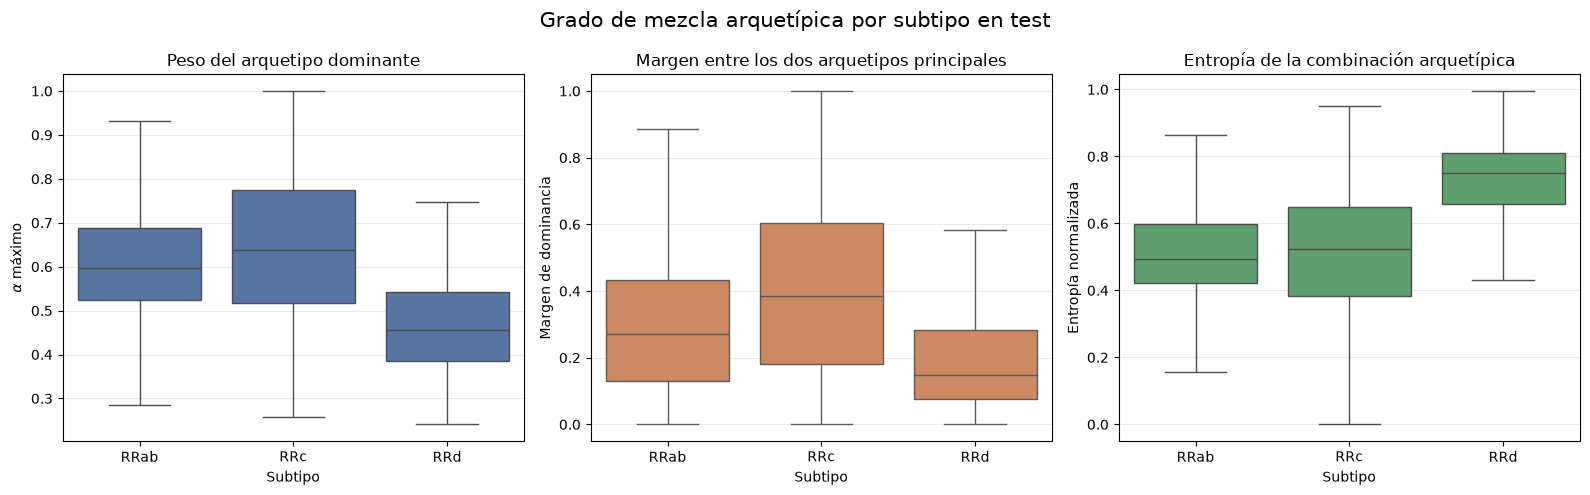

In [13]:
# Orden consistente de los subtipos
orden_subtipos = [
    "RRab",
    "RRc",
    "RRd",
]


# Crear una figura con tres medidas de mezcla
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5),
)


# Peso del arquetipo dominante
sns.boxplot(
    data=df_mezcla_aa,
    x="subtipo_rrlyrae",
    y="alpha_maximo",
    order=orden_subtipos,
    color="#4C72B0",
    showfliers=False,
    ax=axes[0],
)

axes[0].set_title(
    "Peso del arquetipo dominante"
)
axes[0].set_xlabel(
    "Subtipo"
)
axes[0].set_ylabel(
    r"$\alpha$ máximo"
)


# Diferencia entre los dos pesos principales
sns.boxplot(
    data=df_mezcla_aa,
    x="subtipo_rrlyrae",
    y="margen_dominancia",
    order=orden_subtipos,
    color="#DD8452",
    showfliers=False,
    ax=axes[1],
)

axes[1].set_title(
    "Margen entre los dos arquetipos principales"
)
axes[1].set_xlabel(
    "Subtipo"
)
axes[1].set_ylabel(
    "Margen de dominancia"
)


# Entropía de los coeficientes
sns.boxplot(
    data=df_mezcla_aa,
    x="subtipo_rrlyrae",
    y="entropia_normalizada",
    order=orden_subtipos,
    color="#55A868",
    showfliers=False,
    ax=axes[2],
)

axes[2].set_title(
    "Entropía de la combinación arquetípica"
)
axes[2].set_xlabel(
    "Subtipo"
)
axes[2].set_ylabel(
    "Entropía normalizada"
)


for ax in axes:
    ax.grid(
        axis="y",
        alpha=0.25,
    )


fig.suptitle(
    "Grado de mezcla arquetípica por subtipo en test",
    fontsize=15,
)

plt.tight_layout()
plt.show()

In [14]:
# Recuperar los arquetipos de la ejecución representativa
arquetipos_aa = artefactos_representativos[
    "aa_principal_k5"
]["patrones"]


# Reconstruir todas las curvas de test como una
# combinación convexa de los cinco arquetipos
X_test_reconstruido_aa = (
    alphas_aa @ arquetipos_aa
)


# Calcular el error cuadrático medio de cada estrella
mse_individual_aa = np.mean(
    (
        X_test_aa
        - X_test_reconstruido_aa
    ) ** 2,
    axis=1,
)


# Incorporar el error a la tabla de análisis de AA
df_mezcla_aa[
    "mse_reconstruccion"
] = mse_individual_aa


# Resumir la calidad de reconstrucción por subtipo
resumen_reconstruccion_aa = (
    df_mezcla_aa
    .groupby("subtipo_rrlyrae")
    .agg(
        n_observaciones=("observacion_id", "size"),
        mse_medio=("mse_reconstruccion", "mean"),
        mse_mediano=("mse_reconstruccion", "median"),
        mse_percentil_90=(
            "mse_reconstruccion",
            lambda valores: valores.quantile(0.90),
        ),
        mse_maximo=("mse_reconstruccion", "max"),
    )
    .round(6)
    .reset_index()
)


# Verificar que el promedio individual coincida
# con el MSE global calculado anteriormente
comprobacion_mse = pd.Series(
    {
        "mse_global_recalculado": (
            mse_individual_aa.mean()
        ),
        "forma_curvas_reales": X_test_aa.shape,
        "forma_reconstrucciones": (
            X_test_reconstruido_aa.shape
        ),
    },
    name="resultado",
)


display(resumen_reconstruccion_aa)
display(comprobacion_mse)

,subtipo_rrlyrae,n_observaciones,mse_medio,mse_mediano,mse_percentil_90,mse_maximo
0,RRab,14618,0.003149,0.002183,0.006409,0.038718
1,RRc,5272,0.005212,0.003921,0.010841,0.066362
2,RRd,647,0.013947,0.012940,0.021978,0.133350


mse_global_recalculado       0.004019
forma_curvas_reales       (20537, 50)
forma_reconstrucciones    (20537, 50)
Name: resultado, dtype: object

In [15]:
# Seleccionar una estrella representativa de cada subtipo
# usando una regla reproducible y no una elección visual
estrellas_representativas = []

for subtipo in orden_subtipos:

    tabla_subtipo = (
        df_mezcla_aa
        .loc[
            df_mezcla_aa["subtipo_rrlyrae"] == subtipo
        ]
        .copy()
    )

    # Convertir error y entropía en posiciones percentiles
    tabla_subtipo["percentil_mse"] = (
        tabla_subtipo["mse_reconstruccion"]
        .rank(
            method="average",
            pct=True,
        )
    )

    tabla_subtipo["percentil_entropia"] = (
        tabla_subtipo["entropia_normalizada"]
        .rank(
            method="average",
            pct=True,
        )
    )

    # Distancia respecto del centro de ambas distribuciones
    tabla_subtipo["distancia_centro"] = np.sqrt(
        (
            tabla_subtipo["percentil_mse"] - 0.5
        ) ** 2
        +
        (
            tabla_subtipo["percentil_entropia"] - 0.5
        ) ** 2
    )

    estrella_elegida = (
        tabla_subtipo
        .sort_values(
            [
                "distancia_centro",
                "observacion_id",
            ]
        )
        .iloc[0]
        .copy()
    )

    estrellas_representativas.append(
        estrella_elegida
    )


df_estrellas_representativas = (
    pd.DataFrame(estrellas_representativas)
    .reset_index(drop=True)
)


# Recuperar la posición original de cada estrella en test
mapa_indices_test = pd.Series(
    metadata_test.index.to_numpy(),
    index=metadata_test["observacion_id"],
)

df_estrellas_representativas[
    "indice_test"
] = (
    df_estrellas_representativas["observacion_id"]
    .map(mapa_indices_test)
    .astype(int)
)


# Añadir los cinco coeficientes arquetípicos
for indice_arquetipo in range(alphas_aa.shape[1]):

    df_estrellas_representativas[
        f"alpha_{indice_arquetipo + 1}"
    ] = alphas_aa[
        df_estrellas_representativas[
            "indice_test"
        ].to_numpy(),
        indice_arquetipo,
    ]


columnas_mostrar = [
    "observacion_id",
    "subtipo_rrlyrae",
    "mse_reconstruccion",
    "entropia_normalizada",
    "arquetipo_dominante",
    "alpha_1",
    "alpha_2",
    "alpha_3",
    "alpha_4",
    "alpha_5",
]

display(
    df_estrellas_representativas[
        columnas_mostrar
    ].round(4)
)

,observacion_id,subtipo_rrlyrae,mse_reconstruccion,entropia_normalizada,arquetipo_dominante,alpha_1,alpha_2,alpha_3,alpha_4,alpha_5
0,OGLEIV_OGLE-LMC-RRLYR-09434,RRab,0.0022,0.4930,4,0.4567,0.0000,0.0259,0.5174,0.0000
1,OGLEIII_OGLE-LMC-RRLYR-08200,RRc,0.0039,0.5222,5,0.0000,0.3169,0.0000,0.0655,0.6176
2,OGLEIV_OGLE-LMC-RRLYR-13214,RRd,0.0127,0.7505,1,0.4388,0.0715,0.3314,0.0000,0.1584


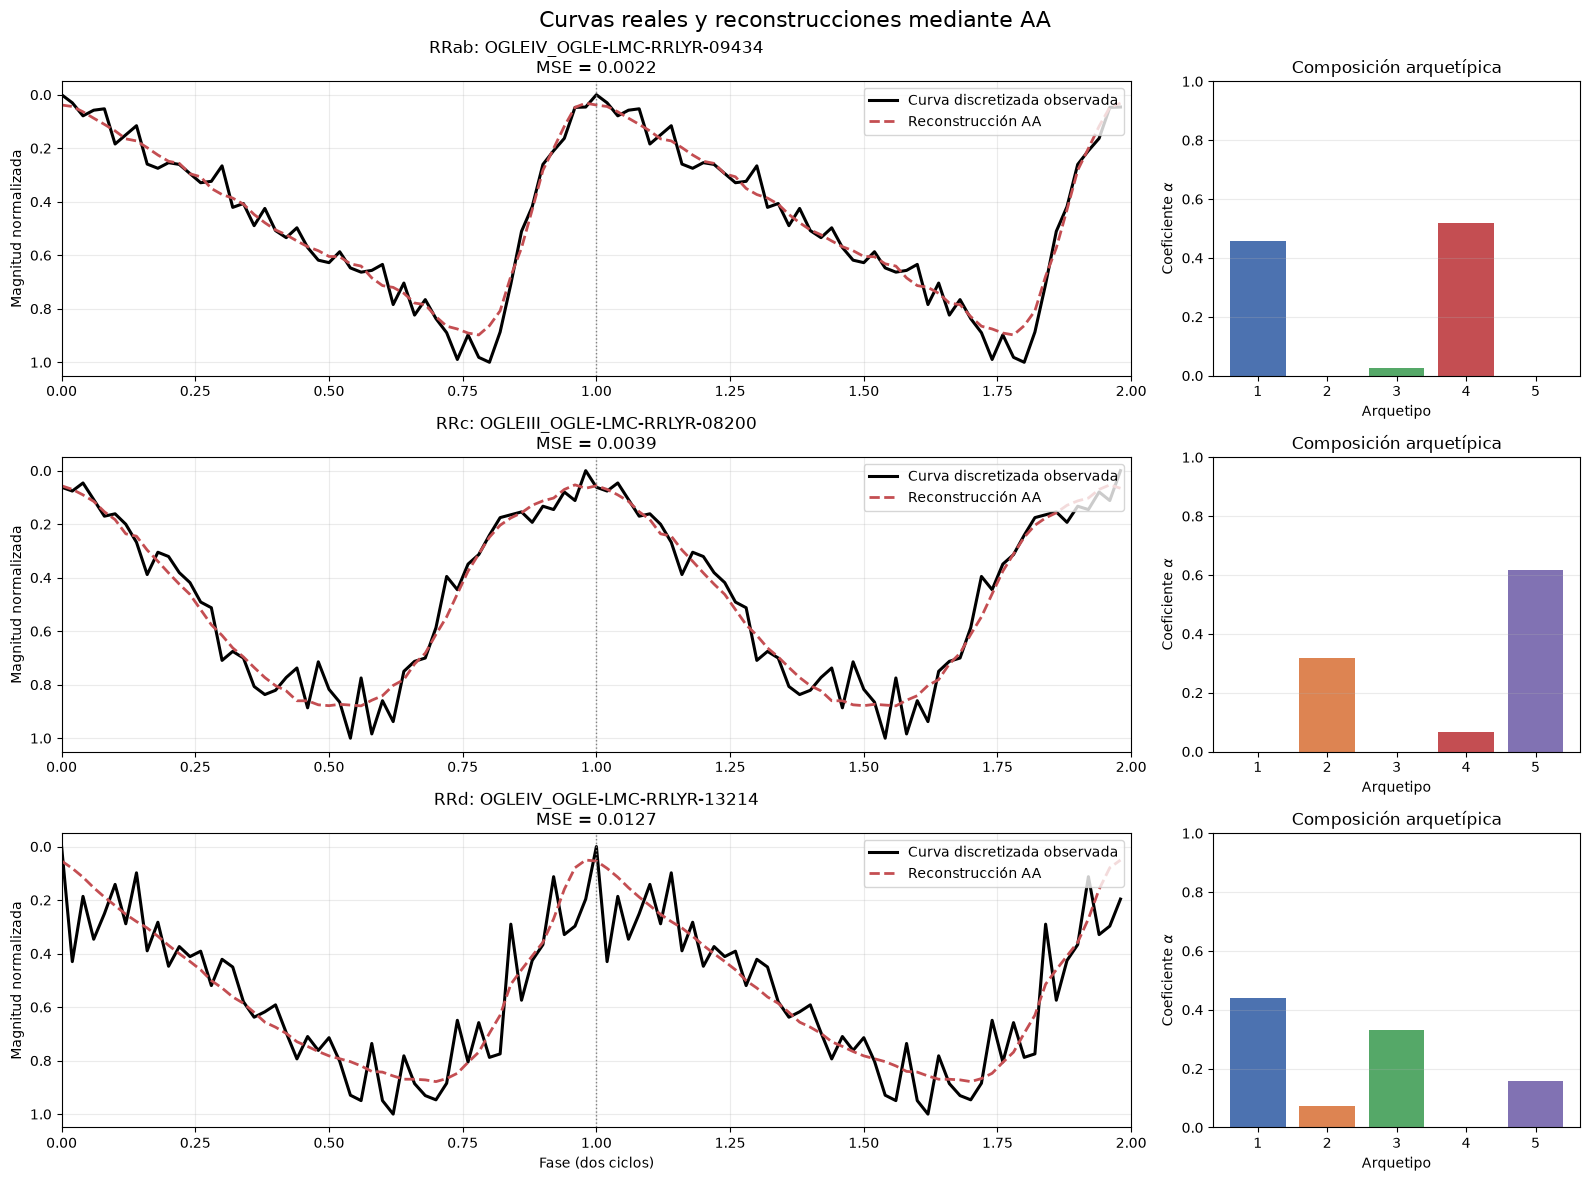

In [16]:
# Colores consistentes para los cinco arquetipos
colores_arquetipos = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52",
    "#8172B3",
]


# Preparar el eje de fase duplicado
n_puntos = X_test_aa.shape[1]

fase_un_ciclo = (
    np.arange(n_puntos) / n_puntos
)

fase_doble = np.concatenate(
    [
        fase_un_ciclo,
        fase_un_ciclo + 1,
    ]
)


# Crear una fila por subtipo:
# curva a la izquierda y coeficientes a la derecha
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 12),
    gridspec_kw={
        "width_ratios": [3.5, 1.2],
    },
)


for fila, estrella in (
    df_estrellas_representativas.iterrows()
):

    indice_test = int(
        estrella["indice_test"]
    )

    subtipo = estrella[
        "subtipo_rrlyrae"
    ]

    observacion_id = estrella[
        "observacion_id"
    ]

    curva_real = X_test_aa[
        indice_test
    ]

    curva_reconstruida = (
        X_test_reconstruido_aa[
            indice_test
        ]
    )

    coeficientes = alphas_aa[
        indice_test
    ]


    # Duplicar la Curva discretizada observada y su reconstrucción
    curva_real_doble = np.tile(
        curva_real,
        2,
    )

    curva_reconstruida_doble = np.tile(
        curva_reconstruida,
        2,
    )


    # Comparación entre Curva discretizada observada y reconstruida
    ax_curva = axes[fila, 0]

    ax_curva.plot(
        fase_doble,
        curva_real_doble,
        color="black",
        linewidth=2.2,
        label="Curva discretizada observada",
    )

    ax_curva.plot(
        fase_doble,
        curva_reconstruida_doble,
        color="#C44E52",
        linewidth=2,
        linestyle="--",
        label="Reconstrucción AA",
    )

    ax_curva.axvline(
        1,
        color="gray",
        linestyle=":",
        linewidth=1,
    )

    ax_curva.set_xlim(
        0,
        2,
    )

    ax_curva.invert_yaxis()

    ax_curva.set_ylabel(
        "Magnitud normalizada"
    )

    ax_curva.set_title(
        f"{subtipo}: {observacion_id}\n"
        f"MSE = {estrella['mse_reconstruccion']:.4f}"
    )

    ax_curva.grid(
        alpha=0.25
    )

    ax_curva.legend(
        loc="upper right"
    )


    # Coeficientes utilizados en la reconstrucción
    ax_alpha = axes[fila, 1]

    ax_alpha.bar(
        np.arange(1, 6),
        coeficientes,
        color=colores_arquetipos,
    )

    ax_alpha.set_ylim(
        0,
        1,
    )

    ax_alpha.set_xticks(
        np.arange(1, 6)
    )

    ax_alpha.set_xlabel(
        "Arquetipo"
    )

    ax_alpha.set_ylabel(
        r"Coeficiente $\alpha$"
    )

    ax_alpha.set_title(
        "Composición arquetípica"
    )

    ax_alpha.grid(
        axis="y",
        alpha=0.25,
    )


axes[-1, 0].set_xlabel(
    "Fase (dos ciclos)"
)

fig.suptitle(
    "Curvas reales y reconstrucciones mediante AA",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [17]:
# Percentiles de error que queremos representar
percentiles_error = {
    "bajo": 0.10,
    "mediano": 0.50,
    "alto": 0.90,
}


# Seleccionar observaciones cercanas a cada percentil
casos_reconstruccion = []

for subtipo in orden_subtipos:

    tabla_subtipo = (
        df_mezcla_aa
        .loc[
            df_mezcla_aa["subtipo_rrlyrae"] == subtipo
        ]
        .copy()
    )

    for nivel_error, percentil in percentiles_error.items():

        mse_objetivo = (
            tabla_subtipo["mse_reconstruccion"]
            .quantile(percentil)
        )

        tabla_subtipo["distancia_mse"] = np.abs(
            tabla_subtipo["mse_reconstruccion"]
            - mse_objetivo
        )

        caso_elegido = (
            tabla_subtipo
            .sort_values(
                [
                    "distancia_mse",
                    "observacion_id",
                ]
            )
            .iloc[0]
            .copy()
        )

        caso_elegido["nivel_error"] = nivel_error
        caso_elegido["percentil_objetivo"] = percentil

        casos_reconstruccion.append(
            caso_elegido
        )


df_casos_reconstruccion = (
    pd.DataFrame(casos_reconstruccion)
    .reset_index(drop=True)
)


# Recuperar la posición de cada observación en test
df_casos_reconstruccion["indice_test"] = (
    df_casos_reconstruccion["observacion_id"]
    .map(mapa_indices_test)
    .astype(int)
)


display(
    df_casos_reconstruccion[
        [
            "subtipo_rrlyrae",
            "nivel_error",
            "observacion_id",
            "mse_reconstruccion",
            "alpha_maximo",
            "entropia_normalizada",
            "arquetipo_dominante",
        ]
    ].round(4)
)

,subtipo_rrlyrae,nivel_error,observacion_id,mse_reconstruccion,alpha_maximo,entropia_normalizada,arquetipo_dominante
0,RRab,bajo,OGLEIV_OGLE-BLG-RRLYR-15581,0.0009,0.6579,0.4528,3
1,RRab,mediano,OGLEIII_OGLE-BLG-RRLYR-09898,0.0022,0.6874,0.4622,3
2,RRab,alto,OGLEIII_OGLE-LMC-RRLYR-14382,0.0064,0.7944,0.4458,1
3,RRc,bajo,OGLEIII_OGLE-BLG-RRLYR-07444,0.0011,0.7911,0.3853,5
4,RRc,mediano,OGLEIII_OGLE-BLG-RRLYR-14134,0.0039,0.5930,0.4199,2
5,RRc,alto,OGLEIV_OGLE-LMC-RRLYR-05178,0.0108,0.4515,0.7752,5
6,RRd,bajo,OGLEIII_OGLE-SMC-RRLYR-0653,0.0065,0.5773,0.6798,5
7,RRd,mediano,OGLEIII_OGLE-LMC-RRLYR-23546,0.0129,0.4892,0.8019,1
8,RRd,alto,OGLEIV_OGLE-SMC-RRLYR-5444,0.0220,0.3558,0.9107,1


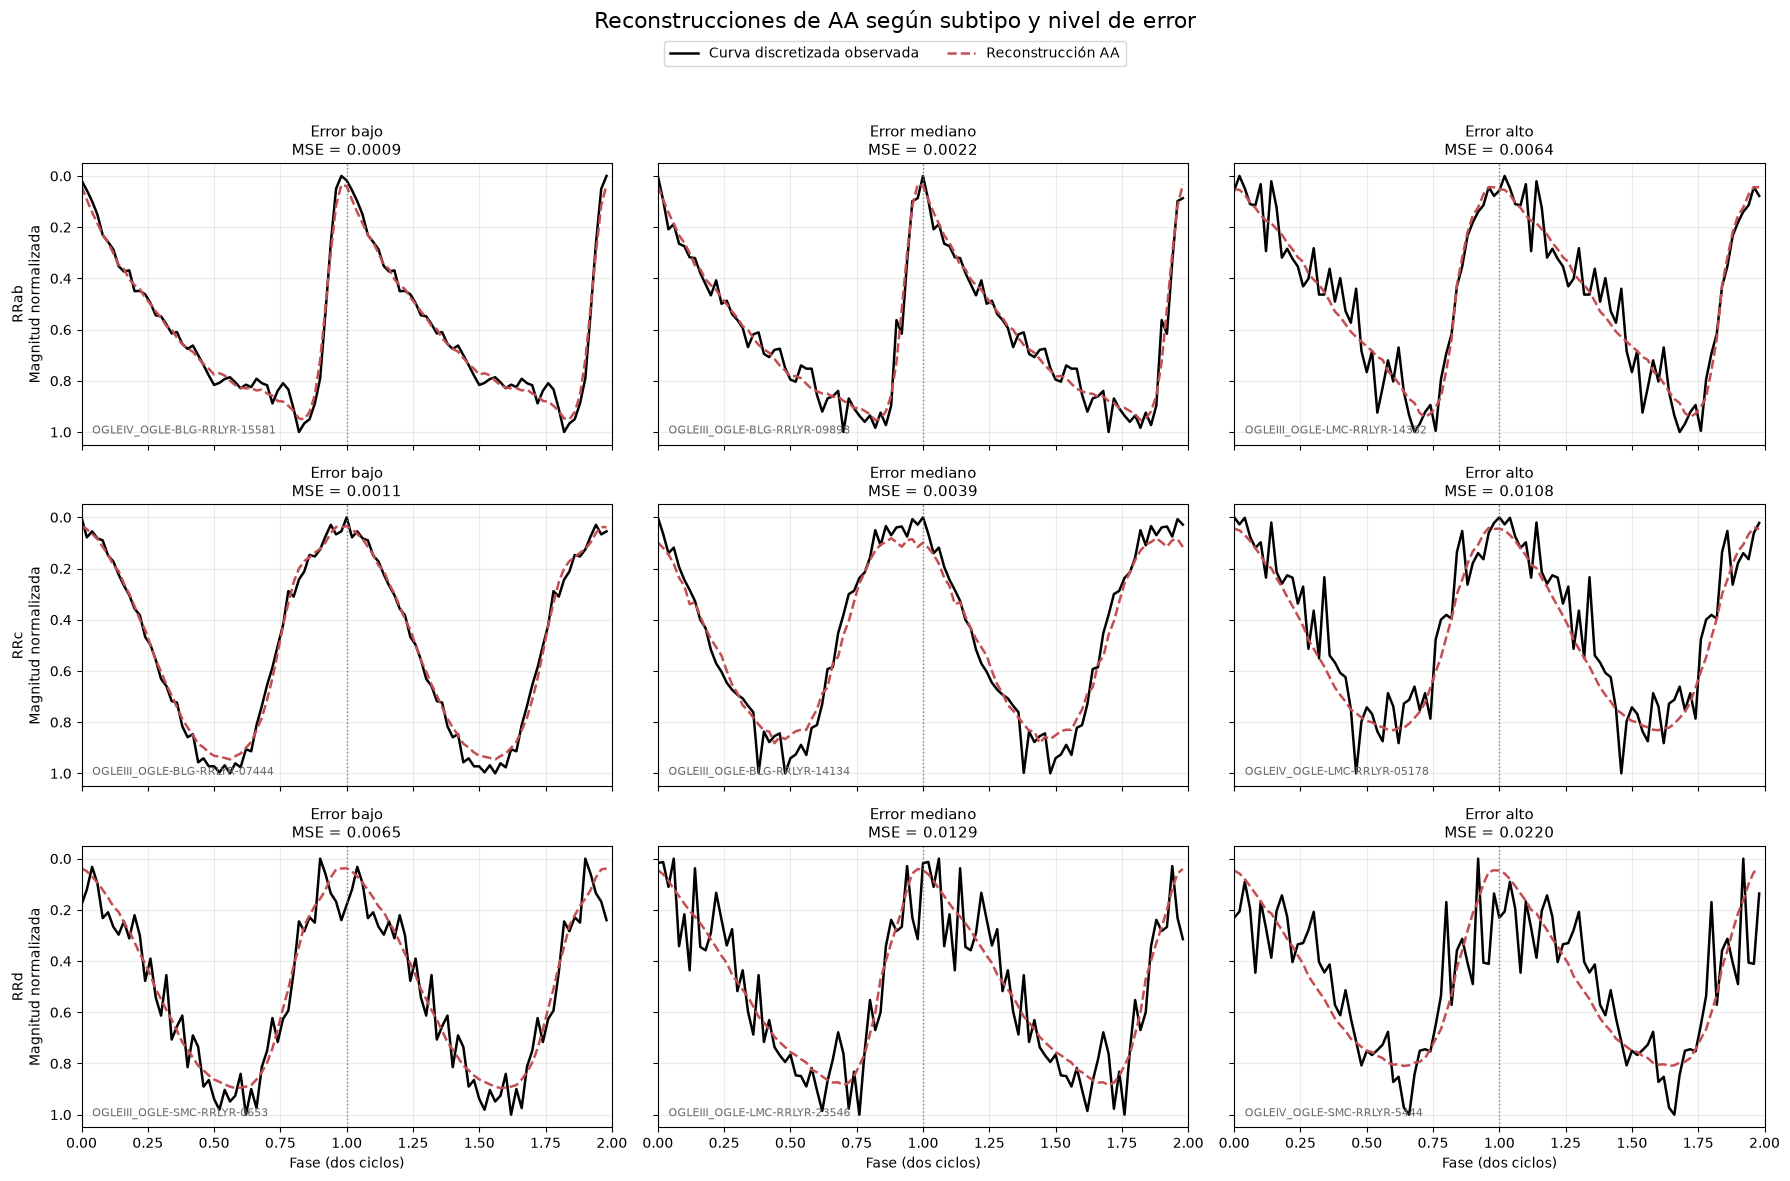

In [18]:
# Orden de las columnas de la figura
orden_niveles_error = [
    "bajo",
    "mediano",
    "alto",
]


# Crear la cuadrícula de reconstrucciones
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 12),
    sharex=True,
    sharey=True,
)


for fila, subtipo in enumerate(orden_subtipos):

    for columna, nivel_error in enumerate(
        orden_niveles_error
    ):

        caso = (
            df_casos_reconstruccion
            .loc[
                (
                    df_casos_reconstruccion[
                        "subtipo_rrlyrae"
                    ] == subtipo
                )
                &
                (
                    df_casos_reconstruccion[
                        "nivel_error"
                    ] == nivel_error
                )
            ]
            .iloc[0]
        )

        indice_test = int(
            caso["indice_test"]
        )

        curva_real = X_test_aa[
            indice_test
        ]

        curva_reconstruida = (
            X_test_reconstruido_aa[
                indice_test
            ]
        )

        ax = axes[
            fila,
            columna,
        ]


        # Mostrar dos ciclos completos
        ax.plot(
            fase_doble,
            np.tile(curva_real, 2),
            color="black",
            linewidth=1.8,
            label="Curva discretizada observada",
        )

        ax.plot(
            fase_doble,
            np.tile(curva_reconstruida, 2),
            color="#C44E52",
            linewidth=1.8,
            linestyle="--",
            label="Reconstrucción AA",
        )

        ax.axvline(
            1,
            color="gray",
            linestyle=":",
            linewidth=1,
        )

        ax.set_xlim(
            0,
            2,
        )

        ax.invert_yaxis()

        ax.grid(
            alpha=0.25
        )

        ax.set_title(
            f"Error {nivel_error}\n"
            f"MSE = {caso['mse_reconstruccion']:.4f}",
            fontsize=11,
        )

        # Identificador de la observación
        ax.text(
            0.02,
            0.04,
            caso["observacion_id"],
            transform=ax.transAxes,
            fontsize=8,
            color="dimgray",
        )

        if columna == 0:
            ax.set_ylabel(
                f"{subtipo}\nMagnitud normalizada"
            )

        if fila == 2:
            ax.set_xlabel(
                "Fase (dos ciclos)"
            )


# Usar una sola leyenda para toda la figura
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.96),
)

fig.suptitle(
    "Reconstrucciones de AA según subtipo y nivel de error",
    fontsize=16,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()

In [19]:
# Seleccionar las cinco ejecuciones de AA
df_aa_seleccion = (
    df_seleccion
    .loc[
        df_seleccion["familia_test"]
        == "aa_principal_k5"
    ]
    .sort_values("seed_modelo")
    .copy()
)


resultados_mezcla_semillas = []

for _, ejecucion in df_aa_seleccion.iterrows():

    experiment_id = ejecucion["experiment_id"]
    seed_modelo = int(ejecucion["seed_modelo"])

    # Cargar los coeficientes obtenidos en test
    alphas_semilla = np.load(
        RUTA_ARTEFACTOS_TEST
        / experiment_id
        / "alphas_test.npy"
    )

    # Ordenar los pesos de cada estrella
    alphas_ordenados_semilla = np.sort(
        alphas_semilla,
        axis=1,
    )[:, ::-1]

    # Calcular la entropía normalizada
    alphas_seguras_semilla = np.clip(
        alphas_semilla,
        1e-12,
        1,
    )

    entropia_semilla = (
        -np.sum(
            alphas_seguras_semilla
            * np.log(alphas_seguras_semilla),
            axis=1,
        )
        / np.log(alphas_semilla.shape[1])
    )

    # Crear una tabla temporal por estrella
    tabla_semilla = pd.DataFrame(
        {
            "seed_modelo": seed_modelo,
            "subtipo_rrlyrae": (
                metadata_test["subtipo_rrlyrae"]
                .to_numpy()
            ),
            "alpha_maximo": (
                alphas_ordenados_semilla[:, 0]
            ),
            "margen_dominancia": (
                alphas_ordenados_semilla[:, 0]
                - alphas_ordenados_semilla[:, 1]
            ),
            "entropia_normalizada": entropia_semilla,
            "n_arquetipos_alpha_010": (
                alphas_semilla >= 0.10
            ).sum(axis=1),
        }
    )

    # Resumir cada subtipo dentro de la semilla
    resumen_semilla = (
        tabla_semilla
        .groupby("subtipo_rrlyrae")
        .agg(
            alpha_maximo_medio=(
                "alpha_maximo",
                "mean",
            ),
            margen_medio=(
                "margen_dominancia",
                "mean",
            ),
            entropia_media=(
                "entropia_normalizada",
                "mean",
            ),
            arquetipos_activos_media=(
                "n_arquetipos_alpha_010",
                "mean",
            ),
        )
        .reset_index()
    )

    resumen_semilla["seed_modelo"] = seed_modelo

    resultados_mezcla_semillas.append(
        resumen_semilla
    )


# Unir los resultados de las cinco semillas
df_robustez_mezcla_aa = pd.concat(
    resultados_mezcla_semillas,
    ignore_index=True,
)


# Resumir la variación entre semillas
resumen_robustez_mezcla_aa = (
    df_robustez_mezcla_aa
    .groupby("subtipo_rrlyrae")
    .agg(
        alpha_maximo_media=(
            "alpha_maximo_medio",
            "mean",
        ),
        alpha_maximo_std=(
            "alpha_maximo_medio",
            "std",
        ),
        margen_media=(
            "margen_medio",
            "mean",
        ),
        margen_std=(
            "margen_medio",
            "std",
        ),
        entropia_media=(
            "entropia_media",
            "mean",
        ),
        entropia_std=(
            "entropia_media",
            "std",
        ),
        arquetipos_activos_media=(
            "arquetipos_activos_media",
            "mean",
        ),
        arquetipos_activos_std=(
            "arquetipos_activos_media",
            "std",
        ),
    )
    .round(4)
    .reset_index()
)


display(
    df_robustez_mezcla_aa
    .sort_values(
        [
            "seed_modelo",
            "subtipo_rrlyrae",
        ]
    )
    .round(4)
)

display(resumen_robustez_mezcla_aa)

,subtipo_rrlyrae,alpha_maximo_medio,margen_medio,entropia_media,arquetipos_activos_media,seed_modelo
0,RRab,0.6068,0.2958,0.5093,2.2992,0
1,RRc,0.6432,0.3978,0.5202,2.3420,0
2,RRd,0.4719,0.1956,0.7266,3.1963,0
3,RRab,0.6068,0.2958,0.5093,2.2992,1
4,RRc,0.6432,0.3978,0.5202,2.3420,1
5,RRd,0.4719,0.1956,0.7266,3.1963,1
6,RRab,0.6068,0.2958,0.5094,2.2992,2
7,RRc,0.6432,0.3977,0.5203,2.3424,2
8,RRd,0.4719,0.1956,0.7267,3.1963,2
9,RRab,0.6068,0.2958,0.5094,2.2992,3


,subtipo_rrlyrae,alpha_maximo_media,alpha_maximo_std,margen_media,margen_std,entropia_media,entropia_std,arquetipos_activos_media,arquetipos_activos_std
0,RRab,0.6068,0.0,0.2958,0.0000,0.5093,0.0,2.2992,0.0000
1,RRc,0.6432,0.0,0.3978,0.0001,0.5202,0.0,2.3421,0.0002
2,RRd,0.4719,0.0,0.1956,0.0000,0.7267,0.0,3.1963,0.0000


In [20]:
# Añadir el identificador de la estrella física
df_mezcla_aa["star_id_base"] = (
    metadata_test["star_id_base"]
    .to_numpy()
)


# Obtener una fila por estrella física para evitar
# considerar observaciones repetidas como independientes
metricas_mezcla = [
    "alpha_maximo",
    "margen_dominancia",
    "entropia_normalizada",
    "n_arquetipos_alpha_010",
]

df_mezcla_estrellas = (
    df_mezcla_aa
    .groupby(
        [
            "star_id_base",
            "subtipo_rrlyrae",
        ],
        as_index=False,
    )[metricas_mezcla]
    .mean()
)


# Prueba global de Kruskal-Wallis
resultados_globales = []

for metrica in metricas_mezcla:

    grupos = [
        df_mezcla_estrellas
        .loc[
            df_mezcla_estrellas["subtipo_rrlyrae"]
            == subtipo,
            metrica,
        ]
        .to_numpy()
        for subtipo in orden_subtipos
    ]

    estadistico, p_valor = kruskal(
        *grupos
    )

    resultados_globales.append(
        {
            "metrica": metrica,
            "estadistico_kruskal": estadistico,
            "p_valor": p_valor,
        }
    )


df_pruebas_globales = pd.DataFrame(
    resultados_globales
)


# Comparaciones específicas de RRd frente a RRab y RRc
comparaciones = [
    ("RRd", "RRab"),
    ("RRd", "RRc"),
]

resultados_pares = []

for metrica in metricas_mezcla:

    for subtipo_1, subtipo_2 in comparaciones:

        valores_1 = (
            df_mezcla_estrellas
            .loc[
                df_mezcla_estrellas["subtipo_rrlyrae"]
                == subtipo_1,
                metrica,
            ]
            .to_numpy()
        )

        valores_2 = (
            df_mezcla_estrellas
            .loc[
                df_mezcla_estrellas["subtipo_rrlyrae"]
                == subtipo_2,
                metrica,
            ]
            .to_numpy()
        )

        estadistico_u, p_valor = mannwhitneyu(
            valores_1,
            valores_2,
            alternative="two-sided",
        )

        # Correlación biserial de rangos:
        # positiva significa valores mayores en RRd
        efecto_biserial = (
            2 * estadistico_u
            / (len(valores_1) * len(valores_2))
            - 1
        )

        resultados_pares.append(
            {
                "metrica": metrica,
                "comparacion": (
                    f"{subtipo_1} vs {subtipo_2}"
                ),
                "n_1": len(valores_1),
                "n_2": len(valores_2),
                "p_valor": p_valor,
                "efecto_biserial": efecto_biserial,
            }
        )


df_pruebas_pares = pd.DataFrame(
    resultados_pares
)


# Corrección de Holm para las ocho comparaciones
orden_p = np.argsort(
    df_pruebas_pares["p_valor"].to_numpy()
)

p_ordenados = (
    df_pruebas_pares["p_valor"]
    .to_numpy()[orden_p]
)

n_pruebas = len(p_ordenados)

p_ajustados_ordenados = np.maximum.accumulate(
    [
        min(
            p_valor * (n_pruebas - posicion),
            1,
        )
        for posicion, p_valor
        in enumerate(p_ordenados)
    ]
)

p_ajustados = np.empty(
    n_pruebas
)

p_ajustados[orden_p] = (
    p_ajustados_ordenados
)

df_pruebas_pares[
    "p_ajustado_holm"
] = p_ajustados


print(
    "Estrellas físicas analizadas:",
    df_mezcla_estrellas["star_id_base"].nunique(),
)

display(df_pruebas_globales)
display(
    df_pruebas_pares[
        [
            "metrica",
            "comparacion",
            "n_1",
            "n_2",
            "p_valor",
            "p_ajustado_holm",
            "efecto_biserial",
        ]
    ].round(4)
)

Estrellas físicas analizadas: 14014


,metrica,estadistico_kruskal,p_valor
0,alpha_maximo,687.098317,6.287763e-150
1,margen_dominancia,691.747458,6.151034e-151
2,entropia_normalizada,803.896256,2.729895e-175
3,n_arquetipos_alpha_010,713.872017,9.652974e-156


,metrica,comparacion,n_1,n_2,p_valor,p_ajustado_holm,efecto_biserial
0,alpha_maximo,RRd vs RRab,443,9875,0.0,0.0,-0.6351
1,alpha_maximo,RRd vs RRc,443,3696,0.0,0.0,-0.6451
2,margen_dominancia,RRd vs RRab,443,9875,0.0,0.0,-0.3126
3,margen_dominancia,RRd vs RRc,443,3696,0.0,0.0,-0.5102
4,entropia_normalizada,RRd vs RRab,443,9875,0.0,0.0,0.8127
5,entropia_normalizada,RRd vs RRc,443,3696,0.0,0.0,0.7012
6,n_arquetipos_alpha_010,RRd vs RRab,443,9875,0.0,0.0,0.6893
7,n_arquetipos_alpha_010,RRd vs RRc,443,3696,0.0,0.0,0.6029


In [21]:
# Determinar qué subtipo domina cada arquetipo
# según la asignación dura de AA
composicion_aa = (
    df_composicion_grupos
    .loc[
        df_composicion_grupos["familia_test"]
        == "aa_principal_k5"
    ]
    .copy()
)

subtipo_dominante_arquetipo = (
    composicion_aa
    .sort_values(
        [
            "grupo",
            "n_observaciones",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .drop_duplicates("grupo")
    .set_index("grupo")["subtipo_rrlyrae"]
    .to_dict()
)


# Crear una tabla con los alphas y la estrella física
columnas_alphas = [
    f"alpha_{indice + 1}"
    for indice in range(alphas_aa.shape[1])
]

df_alphas_estrellas = pd.DataFrame(
    alphas_aa,
    columns=columnas_alphas,
)

df_alphas_estrellas["star_id_base"] = (
    metadata_test["star_id_base"]
    .to_numpy()
)

df_alphas_estrellas["subtipo_rrlyrae"] = (
    metadata_test["subtipo_rrlyrae"]
    .to_numpy()
)


# Promediar los coeficientes cuando una estrella física
# posee más de una observación
df_alphas_estrellas = (
    df_alphas_estrellas
    .groupby(
        [
            "star_id_base",
            "subtipo_rrlyrae",
        ],
        as_index=False,
    )[columnas_alphas]
    .mean()
)


# Identificar los dos arquetipos de mayor peso
matriz_alphas_estrellas = (
    df_alphas_estrellas[columnas_alphas]
    .to_numpy()
)

dos_principales = (
    np.argsort(
        matriz_alphas_estrellas,
        axis=1,
    )[:, -2:][:, ::-1]
    + 1
)

df_alphas_estrellas["arquetipo_1"] = (
    dos_principales[:, 0]
)

df_alphas_estrellas["arquetipo_2"] = (
    dos_principales[:, 1]
)


# Clasificar la naturaleza del par dominante
def clasificar_par_arquetipos(fila):

    subtipo_1 = subtipo_dominante_arquetipo[
        fila["arquetipo_1"]
    ]

    subtipo_2 = subtipo_dominante_arquetipo[
        fila["arquetipo_2"]
    ]

    return "–".join(
        sorted(
            [
                subtipo_1,
                subtipo_2,
            ]
        )
    )


df_alphas_estrellas["tipo_par"] = (
    df_alphas_estrellas.apply(
        clasificar_par_arquetipos,
        axis=1,
    )
)


# Resumir los tipos de pares por subtipo real
tabla_pares_arquetipos = (
    df_alphas_estrellas
    .groupby(
        [
            "subtipo_rrlyrae",
            "tipo_par",
        ]
    )
    .size()
    .rename("n_estrellas")
    .reset_index()
)

tabla_pares_arquetipos[
    "porcentaje_subtipo"
] = (
    tabla_pares_arquetipos["n_estrellas"]
    / tabla_pares_arquetipos
      .groupby("subtipo_rrlyrae")["n_estrellas"]
      .transform("sum")
    * 100
)


print(
    "Subtipo dominante de cada arquetipo:",
    subtipo_dominante_arquetipo,
)

display(
    tabla_pares_arquetipos
    .sort_values(
        [
            "subtipo_rrlyrae",
            "porcentaje_subtipo",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(2)
)

Subtipo dominante de cada arquetipo: {1: 'RRab', 2: 'RRc', 3: 'RRab', 4: 'RRab', 5: 'RRc'}


,subtipo_rrlyrae,tipo_par,n_estrellas,porcentaje_subtipo
0,RRab,RRab–RRab,9182,92.98
1,RRab,RRab–RRc,653,6.61
2,RRab,RRc–RRc,40,0.41
4,RRc,RRab–RRc,1834,49.62
5,RRc,RRc–RRc,1818,49.19
3,RRc,RRab–RRab,44,1.19
7,RRd,RRab–RRc,267,60.27
6,RRd,RRab–RRab,131,29.57
8,RRd,RRc–RRc,45,10.16


In [22]:
# Almacenar la proporción de pares mixtos
# obtenida en cada semilla de AA
resultados_pares_semillas = []


for _, ejecucion in df_aa_seleccion.iterrows():

    experiment_id = ejecucion["experiment_id"]
    seed_modelo = int(ejecucion["seed_modelo"])

    ruta_semilla = (
        RUTA_ARTEFACTOS_TEST
        / experiment_id
    )

    # Cargar los artefactos de test de la semilla
    grupos_semilla = np.load(
        ruta_semilla / "grupos_test.npy"
    )

    alphas_semilla = np.load(
        ruta_semilla / "alphas_test.npy"
    )


    # Determinar el subtipo dominante de cada arquetipo
    tabla_grupos_semilla = pd.DataFrame(
        {
            "grupo": grupos_semilla.astype(int) + 1,
            "subtipo_rrlyrae": (
                metadata_test["subtipo_rrlyrae"]
                .to_numpy()
            ),
        }
    )

    subtipo_por_arquetipo = (
        pd.crosstab(
            tabla_grupos_semilla["grupo"],
            tabla_grupos_semilla["subtipo_rrlyrae"],
        )
        .idxmax(axis=1)
        .to_dict()
    )


    # Construir una tabla de coeficientes por observación
    columnas_alphas_semilla = [
        f"alpha_{indice + 1}"
        for indice in range(alphas_semilla.shape[1])
    ]

    tabla_alphas_semilla = pd.DataFrame(
        alphas_semilla,
        columns=columnas_alphas_semilla,
    )

    tabla_alphas_semilla["star_id_base"] = (
        metadata_test["star_id_base"]
        .to_numpy()
    )

    tabla_alphas_semilla["subtipo_rrlyrae"] = (
        metadata_test["subtipo_rrlyrae"]
        .to_numpy()
    )


    # Promediar cuando una estrella física posee
    # más de una observación
    tabla_alphas_semilla = (
        tabla_alphas_semilla
        .groupby(
            [
                "star_id_base",
                "subtipo_rrlyrae",
            ],
            as_index=False,
        )[columnas_alphas_semilla]
        .mean()
    )


    # Identificar los dos arquetipos principales
    matriz_alphas_semilla = (
        tabla_alphas_semilla[
            columnas_alphas_semilla
        ]
        .to_numpy()
    )

    dos_principales_semilla = (
        np.argsort(
            matriz_alphas_semilla,
            axis=1,
        )[:, -2:][:, ::-1]
        + 1
    )


    # Comprobar si pertenecen a tipos dominantes distintos
    tipos_1 = np.array(
        [
            subtipo_por_arquetipo[indice]
            for indice in dos_principales_semilla[:, 0]
        ]
    )

    tipos_2 = np.array(
        [
            subtipo_por_arquetipo[indice]
            for indice in dos_principales_semilla[:, 1]
        ]
    )

    tabla_alphas_semilla["par_mixto_rrab_rrc"] = (
        (
            (tipos_1 == "RRab")
            & (tipos_2 == "RRc")
        )
        |
        (
            (tipos_1 == "RRc")
            & (tipos_2 == "RRab")
        )
    )


    # Calcular el porcentaje de pares mixtos por subtipo
    resumen_semilla = (
        tabla_alphas_semilla
        .groupby("subtipo_rrlyrae")
        ["par_mixto_rrab_rrc"]
        .mean()
        .mul(100)
        .rename("porcentaje_par_mixto")
        .reset_index()
    )

    resumen_semilla["seed_modelo"] = seed_modelo

    resultados_pares_semillas.append(
        resumen_semilla
    )


# Unir los resultados de las cinco semillas
df_robustez_pares_aa = pd.concat(
    resultados_pares_semillas,
    ignore_index=True,
)


# Tabla compacta con una columna por semilla
tabla_pares_por_semilla = (
    df_robustez_pares_aa
    .pivot(
        index="subtipo_rrlyrae",
        columns="seed_modelo",
        values="porcentaje_par_mixto",
    )
    .round(2)
)


# Resumen de estabilidad entre semillas
resumen_robustez_pares = (
    df_robustez_pares_aa
    .groupby("subtipo_rrlyrae")
    .agg(
        porcentaje_medio=(
            "porcentaje_par_mixto",
            "mean",
        ),
        desviacion_entre_semillas=(
            "porcentaje_par_mixto",
            "std",
        ),
        porcentaje_minimo=(
            "porcentaje_par_mixto",
            "min",
        ),
        porcentaje_maximo=(
            "porcentaje_par_mixto",
            "max",
        ),
    )
    .round(2)
    .reset_index()
)


display(tabla_pares_por_semilla)
display(resumen_robustez_pares)

seed_modelo,0,1,2,3,4
subtipo_rrlyrae,,,,,
RRab,6.61,6.61,6.61,6.61,6.61
RRc,49.62,49.62,49.62,49.62,49.62
RRd,60.27,60.27,60.50,60.50,60.27


,subtipo_rrlyrae,porcentaje_medio,desviacion_entre_semillas,porcentaje_minimo,porcentaje_maximo
0,RRab,6.61,0.00,6.61,6.61
1,RRc,49.62,0.00,49.62,49.62
2,RRd,60.36,0.12,60.27,60.50


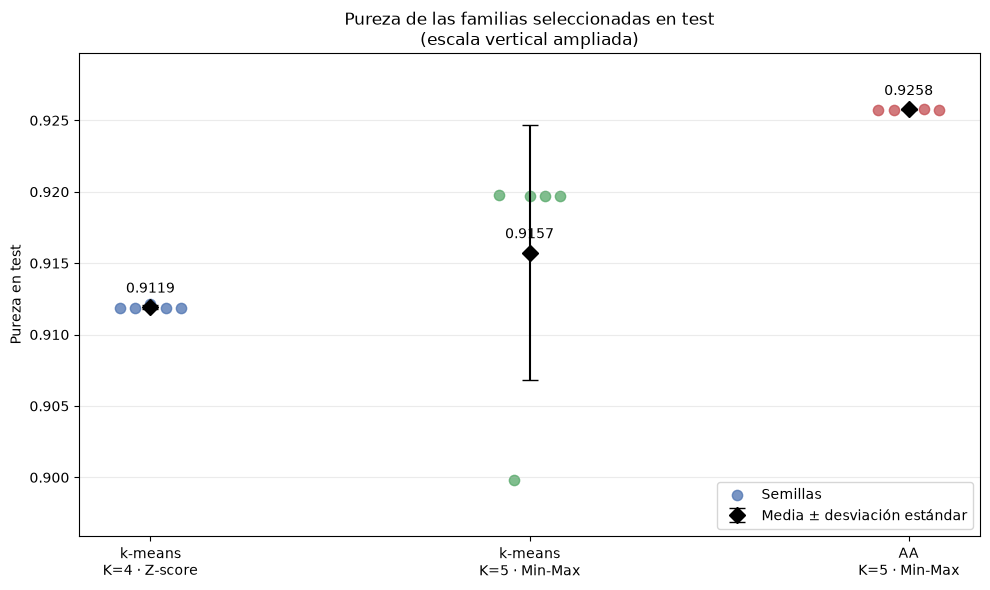

In [23]:
# Cargar las métricas individuales obtenidas
# en la evaluación corregida de test
RUTA_METRICAS_TEST = (
    RUTA_EVALUACION_TEST
    / "metricas_test_ejecuciones.csv"
)

df_metricas_test = pd.read_csv(
    RUTA_METRICAS_TEST
)


# Orden y nombres para la visualización
orden_pureza = [
    "kmeans_principal_k4",
    "kmeans_comparacion_k5",
    "aa_principal_k5",
]

nombres_pureza = {
    "kmeans_principal_k4": (
        "k-means\nK=4 · Z-score"
    ),
    "kmeans_comparacion_k5": (
        "k-means\nK=5 · Min-Max"
    ),
    "aa_principal_k5": (
        "AA\nK=5 · Min-Max"
    ),
}

colores_familias = {
    "kmeans_principal_k4": "#4C72B0",
    "kmeans_comparacion_k5": "#55A868",
    "aa_principal_k5": "#C44E52",
}


# Calcular límites adecuados para mostrar
# todas las ejecuciones sin recortar valores
valores_pureza = (
    df_metricas_test
    .loc[
        df_metricas_test["familia_test"].isin(
            orden_pureza
        ),
        "purity_test",
    ]
)

rango_pureza = (
    valores_pureza.max()
    - valores_pureza.min()
)

margen_vertical = max(
    rango_pureza * 0.15,
    0.002,
)


# Crear la figura
fig, ax = plt.subplots(
    figsize=(10, 6)
)


for posicion, familia in enumerate(orden_pureza):

    valores = (
        df_metricas_test
        .loc[
            df_metricas_test["familia_test"] == familia
        ]
        .sort_values("seed_modelo")
        ["purity_test"]
        .to_numpy()
    )

    media = valores.mean()
    desviacion = valores.std(ddof=1)

    # Separar ligeramente los puntos de las semillas
    desplazamientos = np.linspace(
        -0.08,
        0.08,
        len(valores),
    )

    ax.scatter(
        posicion + desplazamientos,
        valores,
        s=55,
        color=colores_familias[familia],
        alpha=0.75,
        label=(
            "Semillas"
            if posicion == 0
            else None
        ),
    )

    # Mostrar media y desviación estándar
    ax.errorbar(
        posicion,
        media,
        yerr=desviacion,
        fmt="D",
        markersize=8,
        color="black",
        capsize=6,
        linewidth=1.5,
        label=(
            "Media ± desviación estándar"
            if posicion == 0
            else None
        ),
    )

    ax.text(
        posicion,
        media + margen_vertical * 0.20,
        f"{media:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )


ax.set_xticks(
    range(len(orden_pureza))
)

ax.set_xticklabels(
    [
        nombres_pureza[familia]
        for familia in orden_pureza
    ]
)

ax.set_ylabel(
    "Pureza en test"
)

ax.set_ylim(
    valores_pureza.min() - margen_vertical,
    valores_pureza.max() + margen_vertical,
)

ax.set_title(
    "Pureza de las familias seleccionadas en test\n"
    "(escala vertical ampliada)"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    loc="lower right"
)

plt.tight_layout()


# Guardar la figura en los resultados corregidos
RUTA_FIGURA_PUREZA = (
    RUTA_EVALUACION_TEST
    / "pureza_familias_test.png"
)

plt.savefig(
    RUTA_FIGURA_PUREZA,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Hallazgo principal: estructura arquetípica de los subtipos

El análisis mostró que las estrellas RRd no se relacionan claramente con un único arquetipo. Para reconstruir sus curvas, AA suele combinar varios arquetipos con pesos relativamente parecidos. En cambio, las RRab y RRc tienden a depender con mayor fuerza de uno o dos arquetipos.

Esta diferencia no apareció solamente en unas pocas estrellas ni en una ejecución particular. Se observó de forma general en los datos y se repitió prácticamente sin cambios en las cinco semillas del modelo. Las pruebas estadísticas también indicaron que la diferencia entre RRd y los otros subtipos es suficientemente grande como para considerarla relevante y no solo una variación aleatoria.

Al revisar los dos arquetipos con mayor peso en cada estrella, observamos que casi el 93% de las RRab utiliza principalmente dos arquetipos asociados con RRab. En cambio, cerca del 50% de las RRc y el 60% de las RRd combinan un arquetipo asociado con RRab y otro asociado con RRc.

Esto muestra una ventaja descriptiva de AA respecto de K-Means. K-Means asigna cada estrella a un único grupo, mientras que AA permite observar cuánto participa cada arquetipo en la reconstrucción de una estrella. Según esta representación, las RRd tienen una composición más mezclada y variada que RRab y RRc.

Sin embargo, esto no demuestra que las RRd sean una etapa de transformación entre RRab y RRc, ni que AA haya detectado directamente sus dos modos físicos de pulsación. La mezcla también podría estar influida por el desbalance de la muestra y porque las RRd se plegaron utilizando solamente el periodo del primer sobretono. Por ahora, la conclusión correcta es que las curvas RRd presentan una representación arquetípica más distribuida en los datos analizados.

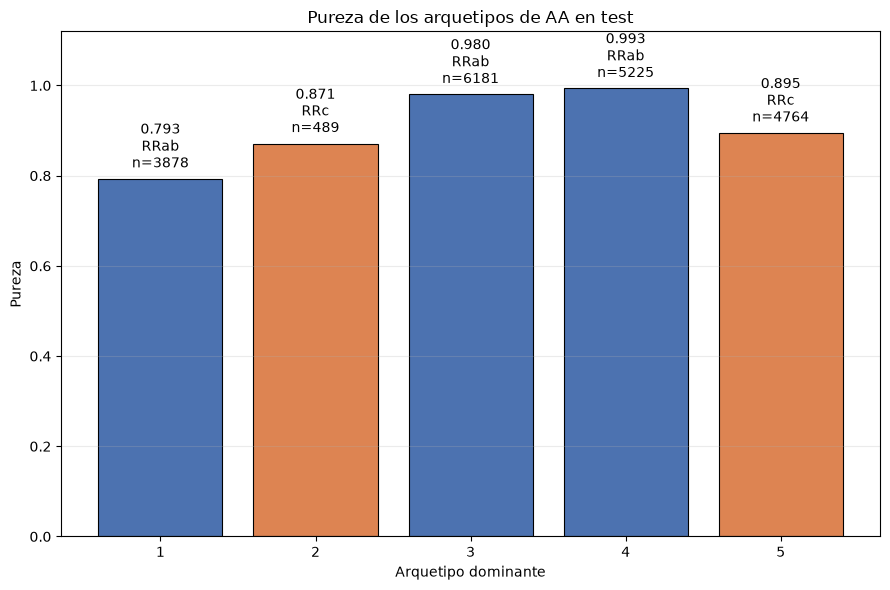

,grupo,n_total,subtipo_dominante,pureza
0,1,3878,RRab,0.7929
1,2,489,RRc,0.8712
2,3,6181,RRab,0.9801
3,4,5225,RRab,0.9933
4,5,4764,RRc,0.8948


In [24]:
# Seleccionar la composición de los grupos dominantes de AA
tabla_pureza_arquetipos = (
    tabla_composicion
    .loc[
        tabla_composicion["familia_test"]
        == "aa_principal_k5"
    ]
    .copy()
)


# Calcular la pureza y el subtipo dominante
columnas_subtipos = [
    "RRab",
    "RRc",
    "RRd",
]

tabla_pureza_arquetipos["subtipo_dominante"] = (
    tabla_pureza_arquetipos[columnas_subtipos]
    .idxmax(axis=1)
)

tabla_pureza_arquetipos["pureza"] = (
    tabla_pureza_arquetipos[columnas_subtipos]
    .max(axis=1)
    / 100
)


# Asignar el color según el subtipo dominante
colores_barras = (
    tabla_pureza_arquetipos["subtipo_dominante"]
    .map(colores_subtipos)
    .tolist()
)


# Crear el gráfico
fig, ax = plt.subplots(
    figsize=(9, 6)
)

barras = ax.bar(
    tabla_pureza_arquetipos["grupo"].astype(str),
    tabla_pureza_arquetipos["pureza"],
    color=colores_barras,
    edgecolor="black",
    linewidth=0.8,
)


# Añadir pureza, subtipo dominante y tamaño del grupo
for barra, (_, fila) in zip(
    barras,
    tabla_pureza_arquetipos.iterrows(),
):

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.015,
        (
            f"{fila['pureza']:.3f}\n"
            f"{fila['subtipo_dominante']}\n"
            f"n={int(fila['n_total'])}"
        ),
        ha="center",
        va="bottom",
        fontsize=10,
    )


ax.set_xlabel(
    "Arquetipo dominante"
)

ax.set_ylabel(
    "Pureza"
)

ax.set_ylim(
    0,
    1.12,
)

ax.set_title(
    "Pureza de los arquetipos de AA en test"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()


# Guardar el gráfico
RUTA_FIGURA_PUREZA_AA = (
    RUTA_EVALUACION_TEST
    / "pureza_arquetipos_aa.png"
)

plt.savefig(
    RUTA_FIGURA_PUREZA_AA,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


display(
    tabla_pureza_arquetipos[
        [
            "grupo",
            "n_total",
            "subtipo_dominante",
            "pureza",
        ]
    ].round(4)
)